# NLP Pipeline & Portfolio Construction

This notebook walks through the two main processing stages of the
replication.  The replication focuses on the **overnight drift
strategy** (Table 1 Panel A and Figure 5 of the paper).  Intraday
headlines are excluded during data cleaning, and no TAQ-based
intraday return windows are computed.

1. **Headline classification** -- submitting cleaned overnight
   headlines (enriched with RavenPack metadata) to OpenAI and
   aggregating the responses into firm-day sentiment scores.
2. **Portfolio construction** -- translating sentiment scores into
   daily long/short trading portfolios using open-to-close drift
   returns.

---
## Setup

In [1]:
import json
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from settings import config

DATA_DIR = Path(config("DATA_DIR"))
OUTPUT_DIR = Path(config("OUTPUT_DIR"))

---
## 1. Generating Batch Requests for OpenAI

Each cleaned headline (scraped from free sources and enriched with
RavenPack entity metadata) is formatted as a JSONL request for the
OpenAI Batch API.  The prompt follows the one described in the
paper: the model is asked whether the headline implies a stock price
increase, decrease, or neither.

Headlines are split into batches (default 40,000 per batch) and
submitted asynchronously.  Below is a single-row example showing
exactly what one request looks like.

In [2]:
from notebook_helper import generate_single_request_jsonl

rp = (
    pd.read_parquet(DATA_DIR / "RAVENPACK_cleaned.parquet")
    if (DATA_DIR / "RAVENPACK_cleaned.parquet").exists()
    else pd.DataFrame()
)

if not rp.empty:
    jsonl_content, mapping_content = generate_single_request_jsonl(rp.head(1).copy())

    display(Markdown("### JSONL Request (formatted)"))
    print(
        json.dumps(
            json.loads(jsonl_content), sort_keys=True, indent=2, separators=(",", ": ")
        )
    )

    display(Markdown("### ID-to-Row Mapping"))
    print(
        json.dumps(
            json.loads(mapping_content),
            sort_keys=True,
            indent=2,
            separators=(",", ": "),
        )
    )

del rp

Wrote requests jsonl: /var/folders/l3/tj6vb0ld2ys1h939jz0qrfrh0000gn/T/tmphjxttlyh/openai_headline_requests.single.jsonl
Number of headlines batched: 1
Wrote id to row mapping json: /var/folders/l3/tj6vb0ld2ys1h939jz0qrfrh0000gn/T/tmphjxttlyh/id_to_row_mapping.single.json


### JSONL Request (formatted)

{
  "body": {
    "messages": [
      {
        "content": "Forget all your previous instructions. Pretend you are a financial expert. You are a financial expert with stock recommendation experience. Answer \"YES\" if good news, \"NO\" if bad news, or \"UNKNOWN\" if uncertain in the first line. Then elaborate with one short and concise sentence on the next line.",
        "role": "system"
      },
      {
        "content": "Is this headline good or bad for the stock price of Kennedy-Wilson Holdings Inc. in the short term?\nHeadline: Kennedy Wilson Acquires Two Multifamily Communities in Seattle for $265 Million",
        "role": "user"
      }
    ],
    "model": "gpt-3.5-turbo",
    "temperature": 0
  },
  "custom_id": "rp-0",
  "method": "POST",
  "url": "/v1/chat/completions"
}


### ID-to-Row Mapping

{
  "rp-0": {
    "date": "2021-10-01",
    "entity_name": "Kennedy-Wilson Holdings Inc.",
    "ticker": "KW"
  }
}


---
## 2. OpenAI Response Format

The model returns one of three labels for each headline:

- **YES** -- headline implies a stock price increase
- **NO** -- headline implies a stock price decrease
- **UNKNOWN** -- no clear directional signal

Below is an example response from a completed batch.

In [3]:
batch_output_path = DATA_DIR / "openai_headline_batch_output.1.jsonl"
if batch_output_path.exists():
    data = pd.read_json(batch_output_path, lines=True).head(1)
    display(Markdown("### Sample OpenAI Batch Response"))
    display(data.iloc[0]["response"])

### Sample OpenAI Batch Response

{'status_code': 200,
 'request_id': 'dde85f7b-47ce-4520-b489-4f96d1e15ec4',
 'body': {'id': 'chatcmpl-DLKkhs3nF6Z2sK154oVKzkcHorsvQ',
  'object': 'chat.completion',
  'created': 1773977031,
  'model': 'gpt-3.5-turbo-0125',
  'choices': [{'index': 0,
    'message': {'role': 'assistant',
     'content': 'YES  \nAcquiring new assets can potentially boost the stock price in the short term.',
     'refusal': None,
     'annotations': []},
    'logprobs': None,
    'finish_reason': 'stop'}],
  'usage': {'prompt_tokens': 115,
   'completion_tokens': 17,
   'total_tokens': 132,
   'prompt_tokens_details': {'cached_tokens': 0, 'audio_tokens': 0},
   'completion_tokens_details': {'reasoning_tokens': 0,
    'audio_tokens': 0,
    'accepted_prediction_tokens': 0,
    'rejected_prediction_tokens': 0}},
  'service_tier': 'default',
  'system_fingerprint': None}}

---
## 3. Firm-Day Sentiment Scores

The pipeline (`create_firmday_score.py`) processes all batch
responses and aggregates them at the firm-day level:

- YES &rarr; score of **+1**
- NO &rarr; score of **-1**
- UNKNOWN &rarr; score of **0**

For each (ticker, date) pair, the total score sum and overall
polarity (positive or negative) are computed.

In [4]:
scores_path = DATA_DIR / "daily_headline_polarity.parquet"
scores = (
    pd.read_parquet(scores_path) if scores_path.exists() else pd.DataFrame()
)
print("Firm-day scores shape:", scores.shape)
display(scores.head())

Firm-day scores shape: (53880, 5)


,ticker,date,n_headlines,score_sum,score
0,A,2021-11-18,1,1,1
1,A,2021-11-23,1,1,1
2,A,2022-06-15,1,1,1
3,A,2022-08-17,2,1,1
4,A,2022-11-22,2,1,1


In [5]:
if not scores.empty:
    summary = (
        scores["score"]
        .value_counts(dropna=False)
        .rename_axis("score")
        .reset_index(name="count")
    )
    summary["share"] = (summary["count"] / summary["count"].sum()).round(4)
    summary = summary.sort_values("score", ignore_index=True)
    display(Markdown("### Score Distribution"))
    display(summary)

del scores

### Score Distribution

,score,count,share
0,-1,1399,0.0260
1,0,37744,0.7005
2,1,14737,0.2735


---
## 4. Classification Distribution

A key diagnostic is how frequently the model assigns each label.
The replication uses **GPT-3.5-Turbo** (because GPT-4-0314 was
deprecated), which produces a substantially larger share of UNKNOWN
classifications compared to the original paper (~67% vs ~35%).
This reduces the number of tradable signals.

In [6]:
label_path = OUTPUT_DIR / "openai_output_label_proportions.csv"
if label_path.exists():
    labels = pd.read_csv(label_path)
    display(Markdown("### Headline Label Proportions"))
    display(labels)

### Headline Label Proportions

,label,proportion_2021_2024_sample_period,proportion_full_sample,count_2021_2024_sample_period,count_full_sample
0,YES,0.273562,0.272604,10072,15292
1,NO,0.031506,0.028629,1160,1606
2,UNKNOWN,0.694932,0.698766,25586,39198


---
## 5. Portfolio Construction (Overnight Drift)

Once firm-day sentiment scores are constructed, they are merged with
CRSP returns.  Portfolios are formed each trading day using
**open-to-close returns** (the drift component for overnight news).
The initial reaction (previous close to open) is also recorded.

- **Long-Short Portfolio** -- buy positive-signal firms and sell
  negative-signal firms (both legs must have at least two firms;
  otherwise enter only one leg).
- **Long-Only Portfolio** -- buy only positive-signal firms.
- **Short-Only Portfolio** -- sell only negative-signal firms.

For Figure 5 replication, two additional restricted variants are
constructed:

- **Not Small** -- market capitalization above the 20th percentile.
- **Price > 5** -- previous day's closing price above $5.

In [7]:
port_path = DATA_DIR / "portfolio_daily_returns.parquet"
port = pd.read_parquet(port_path) if port_path.exists() else pd.DataFrame()
print("Portfolio returns shape:", port.shape)
display(port.head())

del port

Portfolio returns shape: (1088, 20)


,date,n_neg,n_neu,n_pos,n_total,ret_long,n_long,n_short,ret_short,ret_ir_long,ret_ir_short,ret_ls_restricted,ret_ls_not_small,ret_ls_price_gt_5,ret_mkt_vw,trade_long,trade_short,trade_ls,ret_ls,ret_ir_ls
0,2021-10-01,0,5,7,12,0.0,0,0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,True,False,True,0.000000,0.000000
1,2021-10-04,2,13,5,20,-0.030306,4,2,-0.001542,0.005442,0.051936,-0.034116,-0.028099,-0.034116,-0.010693,True,True,True,-0.031848,0.057377
2,2021-10-05,1,25,7,33,0.01095,6,1,0.003886,-0.018285,0.011524,0.029155,0.029155,0.029155,0.006008,True,True,True,0.010950,-0.018285
3,2021-10-06,0,15,13,28,-0.006671,11,0,0.0,-0.002133,0.0,0.000000,0.000000,0.000000,0.011786,True,False,True,-0.006671,-0.002133
4,2021-10-07,1,18,12,31,0.027744,12,1,-0.054348,0.008739,0.114533,-0.050161,-0.050161,-0.050995,0.002413,True,True,True,0.027744,0.008739


---
## 6. Portfolio Size Diagnostics

Because GPT-3.5-Turbo classifies a larger share of headlines as
UNKNOWN, fewer firms appear in the daily portfolios compared to the
original paper.  The chart below shows the number of stocks in the
long and short legs over time.

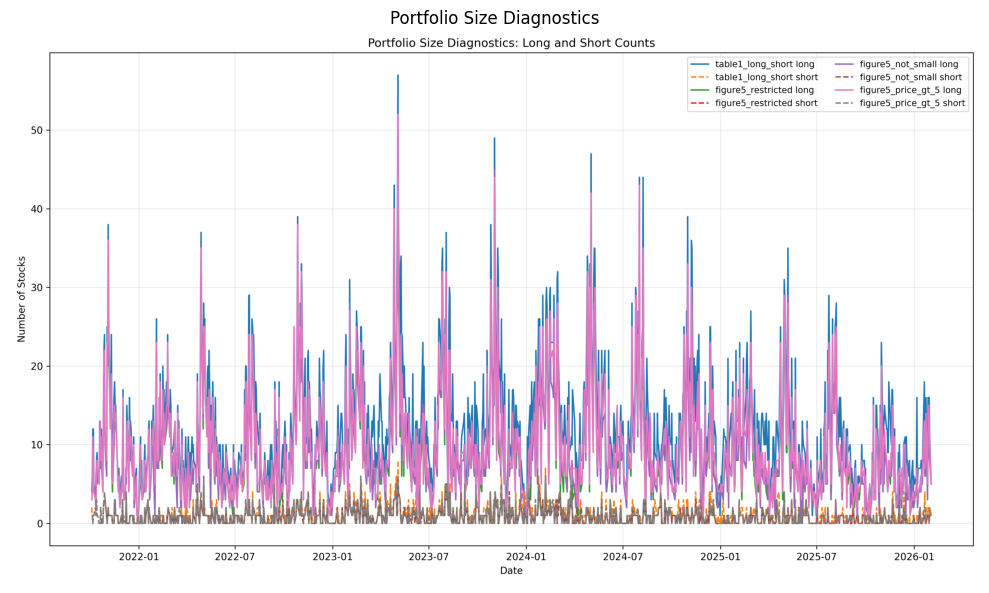

In [8]:
diag_path = OUTPUT_DIR / "portfolio_size_diagnostics_all.png"
if diag_path.exists():
    img = mpimg.imread(str(diag_path))
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("Portfolio Size Diagnostics")
    plt.tight_layout()
    plt.show()

---
## Summary

This notebook covered the two main processing stages:

1. Headlines are submitted to OpenAI, which classifies each as
   YES / NO / UNKNOWN.  These are aggregated into firm-day
   sentiment scores.
2. Sentiment scores are merged with CRSP returns to construct
   daily-rebalanced trading portfolios.

The next notebook presents the replication results: Table 1
(trading performance statistics) and Figure 5 (cumulative returns).